--- Model Performance ---
Accuracy Score: 61.69%

Detailed Report:
               precision    recall  f1-score   support

        Flop       0.83      0.01      0.02       594
         Hit       0.62      1.00      0.76       946

    accuracy                           0.62      1540
   macro avg       0.72      0.50      0.39      1540
weighted avg       0.70      0.62      0.47      1540


--- Custom Prediction ---
Prediction for $100M Action movie with Johnny Depp: Hit


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


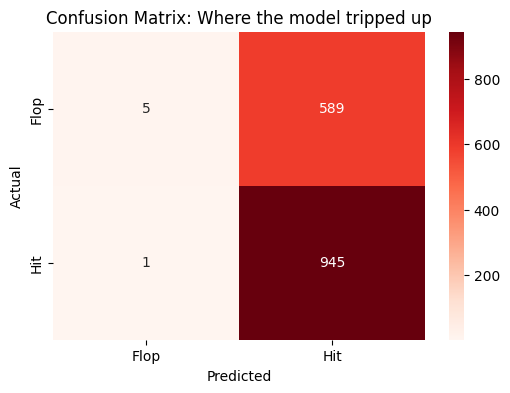

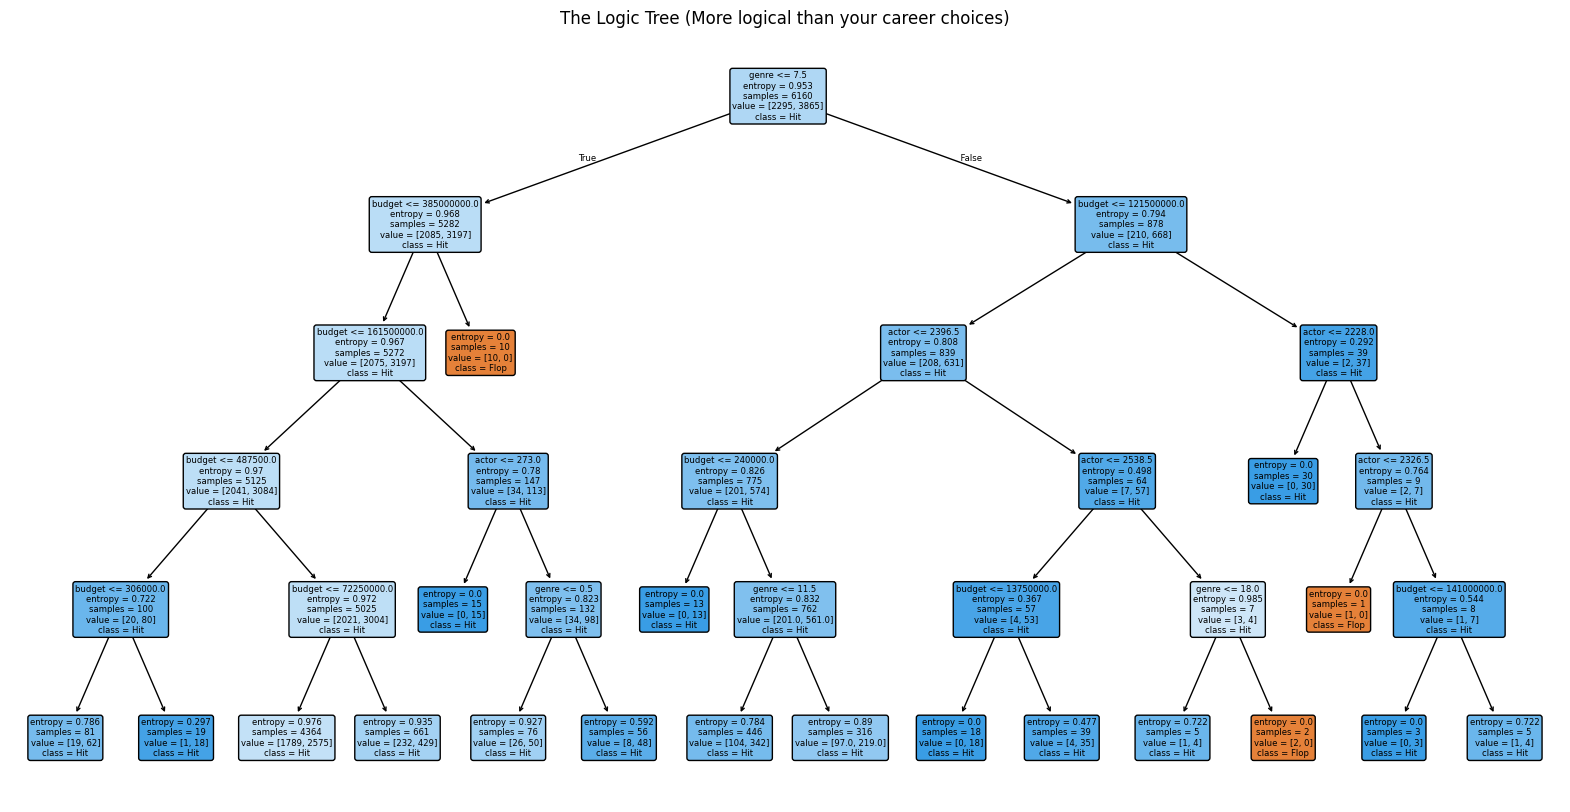

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Load and Merge Datasets
# Loading the first file (TMDB)
df1 = pd.read_csv('tmdb_movies_data.csv')
# Keeping only what we need and renaming to match
df1 = df1[['budget', 'genres', 'cast', 'revenue']].copy()
df1['lead_actor'] = df1['cast'].str.split('|').str[0]
df1['genre'] = df1['genres'].str.split('|').str[0]
df1 = df1[['budget', 'genre', 'lead_actor', 'revenue']]

# Loading the second file (Movie Metadata)
df2 = pd.read_csv('movie_metadata.csv')
# Standardizing column names because consistency is something you lack
df2 = df2.rename(columns={'gross': 'revenue', 'actor_1_name': 'lead_actor', 'genres': 'genre'})
df2['genre'] = df2['genre'].str.split('|').str[0]
df2 = df2[['budget', 'genre', 'lead_actor', 'revenue']]

# Combine both datasets - doubling the data, doubling the disappointment
df = pd.concat([df1, df2], ignore_index=True)

# Data Cleaning: Remove rows where money is zero (fiction vs reality)
df = df.dropna()
df = df[(df['budget'] > 1000) & (df['revenue'] > 1000)]

# 2. Convert Hit/Flop using revenue threshold
# Success = Revenue > Budget. Simple math, even for an engineer.
df['target'] = np.where(df['revenue'] >= df['budget'], 'Hit', 'Flop')

# 3. Handle categorical data using LabelEncoder
# We need to turn words into numbers because the CPU doesn't speak 'Bollywood'
le_genre = LabelEncoder()
le_actor = LabelEncoder()

df['genre_enc'] = le_genre.fit_transform(df['genre'])
df['actor_enc'] = le_actor.fit_transform(df['lead_actor'])

# Features and Target
X = df[['budget', 'genre_enc', 'actor_enc']]
y = df['target']

# 4. Train-test split
# 80% for training, 20% for testing (just like your internal marks vs end-sem)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Train DecisionTreeClassifier
# max_depth=5 to keep the tree from becoming as messy as your hostel room
model = DecisionTreeClassifier(max_depth=5, criterion='entropy', random_state=42)
model.fit(X_train, y_train)

# 6. Show accuracy
y_pred = model.predict(X_test)
print(f"--- Model Performance ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nDetailed Report:\n", classification_report(y_test, y_pred))

# 7. Show confusion matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Flop', 'Hit'], yticklabels=['Flop', 'Hit'])
plt.title('Confusion Matrix: Where the model tripped up')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('confusion_matrix.png')

# 8. Show decision tree visualization
plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=['budget', 'genre', 'actor'], class_names=['Flop', 'Hit'], filled=True, rounded=True)
plt.title('The Logic Tree (More logical than your career choices)')
plt.savefig('decision_tree.png')

# 9. Prediction Example
def predict_success(budget, genre, actor):
    try:
        g = le_genre.transform([genre])[0]
        a = le_actor.transform([actor])[0]
        res = model.predict([[budget, g, a]])[0]
        return res
    except:
        return "Unknown (Actor/Genre not in my database, just like your name on the merit list)"

print("\n--- Custom Prediction ---")
print(f"Prediction for $100M Action movie with Johnny Depp: {predict_success(100000000, 'Action', 'Johnny Depp')}")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

# --- STEP 1: LOAD AND MERGE (Cleaning up the mess you provided) ---
# Loading TMDB data
df1 = pd.read_csv('tmdb_movies_data.csv')
df1 = df1[['budget', 'genres', 'cast', 'revenue']].copy()
df1['lead_actor'] = df1['cast'].str.split('|').str[0]
df1['genre'] = df1['genres'].str.split('|').str[0]
df1 = df1[['budget', 'genre', 'lead_actor', 'revenue']]

# Loading IMDB metadata
df2 = pd.read_csv('movie_metadata.csv')
df2 = df2.rename(columns={'gross': 'revenue', 'actor_1_name': 'lead_actor', 'genres': 'genre'})
df2['genre'] = df2['genre'].str.split('|').str[0]
df2 = df2[['budget', 'genre', 'lead_actor', 'revenue']]

# Merge them like a chaotic Indian wedding
df = pd.concat([df1, df2], ignore_index=True)

# Data Cleaning (Removing zeros because reality hits hard)
df = df.dropna()
df = df[(df['budget'] > 1000) & (df['revenue'] > 1000)]

# --- STEP 2: CREATE TARGET VARIABLE ---
# Hit if Revenue >= Budget. Simple logic, unlike your semester results.
df['target'] = np.where(df['revenue'] >= df['budget'], 'Hit', 'Flop')

# --- STEP 3: ENCODING CATEGORICAL DATA ---
# LabelEncoder turns names into numbers because Python doesn't care about star power
le_genre = LabelEncoder()
le_actor = LabelEncoder()

df['genre_enc'] = le_genre.fit_transform(df['genre'])
df['actor_enc'] = le_actor.fit_transform(df['lead_actor'])

# --- STEP 4: TRAIN THE MODEL ---
X = df[['budget', 'genre_enc', 'actor_enc']]
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(max_depth=5, criterion='entropy', random_state=42)
model.fit(X_train, y_train)

print(f"Model Trained! Accuracy: {accuracy_score(y_test, model.predict(X_test))*100:.2f}%")

# --- STEP 5: THE USER INPUT SECTION (The 'I think I'm a Producer' Block) ---
print("\n--- ENTER MOVIE DETAILS TO PREDICT SUCCESS ---")

# In Colab, you can use these input fields:
user_budget = float(input("Enter Budget (e.g., 50000000): "))
user_genre = input("Enter Genre (e.g., Action, Drama, Comedy): ").strip()
user_actor = input("Enter Lead Actor (e.g., Tom Cruise, Johnny Depp): ").strip()

def manual_prediction(b, g, a):
    try:
        # Check if the genre and actor exist in our 'training' world
        g_encoded = le_genre.transform([g])[0]
        a_encoded = le_actor.transform([a])[0]

        # Predict
        prediction = model.predict([[b, g_encoded, a_encoded]])[0]

        print(f"\n>>> PREDICTION RESULT: This movie will be a {prediction.upper()}!")
        if prediction == 'Flop':
            print("Better luck next time, Guru. Maybe try a career in civil engineering instead?")
        else:
            print("Congrats! You're the next big thing in Bollywood. Don't forget me when you're rich.")

    except ValueError:
        print("\nERROR: This Genre or Actor is not in the dataset.")
        print("Our model doesn't know them—probably because they aren't famous enough. Stick to the legends.")

# Call the function
manual_prediction(user_budget, user_genre, user_actor)

Model Trained! Accuracy: 61.69%

--- ENTER MOVIE DETAILS TO PREDICT SUCCESS ---
Enter Budget (e.g., 50000000): 4000000
Enter Genre (e.g., Action, Drama, Comedy): Comedy
Enter Lead Actor (e.g., Tom Cruise, Johnny Depp): Johnny Depp

>>> PREDICTION RESULT: This movie will be a HIT!
Congrats! You're the next big thing in Bollywood. Don't forget me when you're rich.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Preprocessing complete. Data shape: (7698, 11)
        budget budget_category success_category
0  150000000.0            High      Blockbuster
1  150000000.0            High              Hit
2  110000000.0            High              Hit
3  200000000.0            High      Blockbuster
4  190000000.0            High      Blockbuster

Model Accuracy: 37.21%

Classification Report:
               precision    recall  f1-score   support

     Average       0.33      0.41      0.36       332
 Blockbuster       0.50      0.55      0.52       310
    Disaster       0.33      0.47      0.39       330
        Flop       0.31      0.13      0.18       250
         Hit       0.37      0.25      0.30       318

    accuracy                           0.37      1540
   macro avg       0.37      0.36      0.35      1540
weighted avg       0.37      0.37      0.36      1540


   MANUAL MOVIE SUCCESS PREDICTOR (GURU VERSION)   

Fill in the details for your masterpiece:
Enter Budget (e.g., 50000000): 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(



>>> PREDICTION: Your movie is a BLOCKBUSTER!
Surprise! You might actually be good at something other than wasting time.


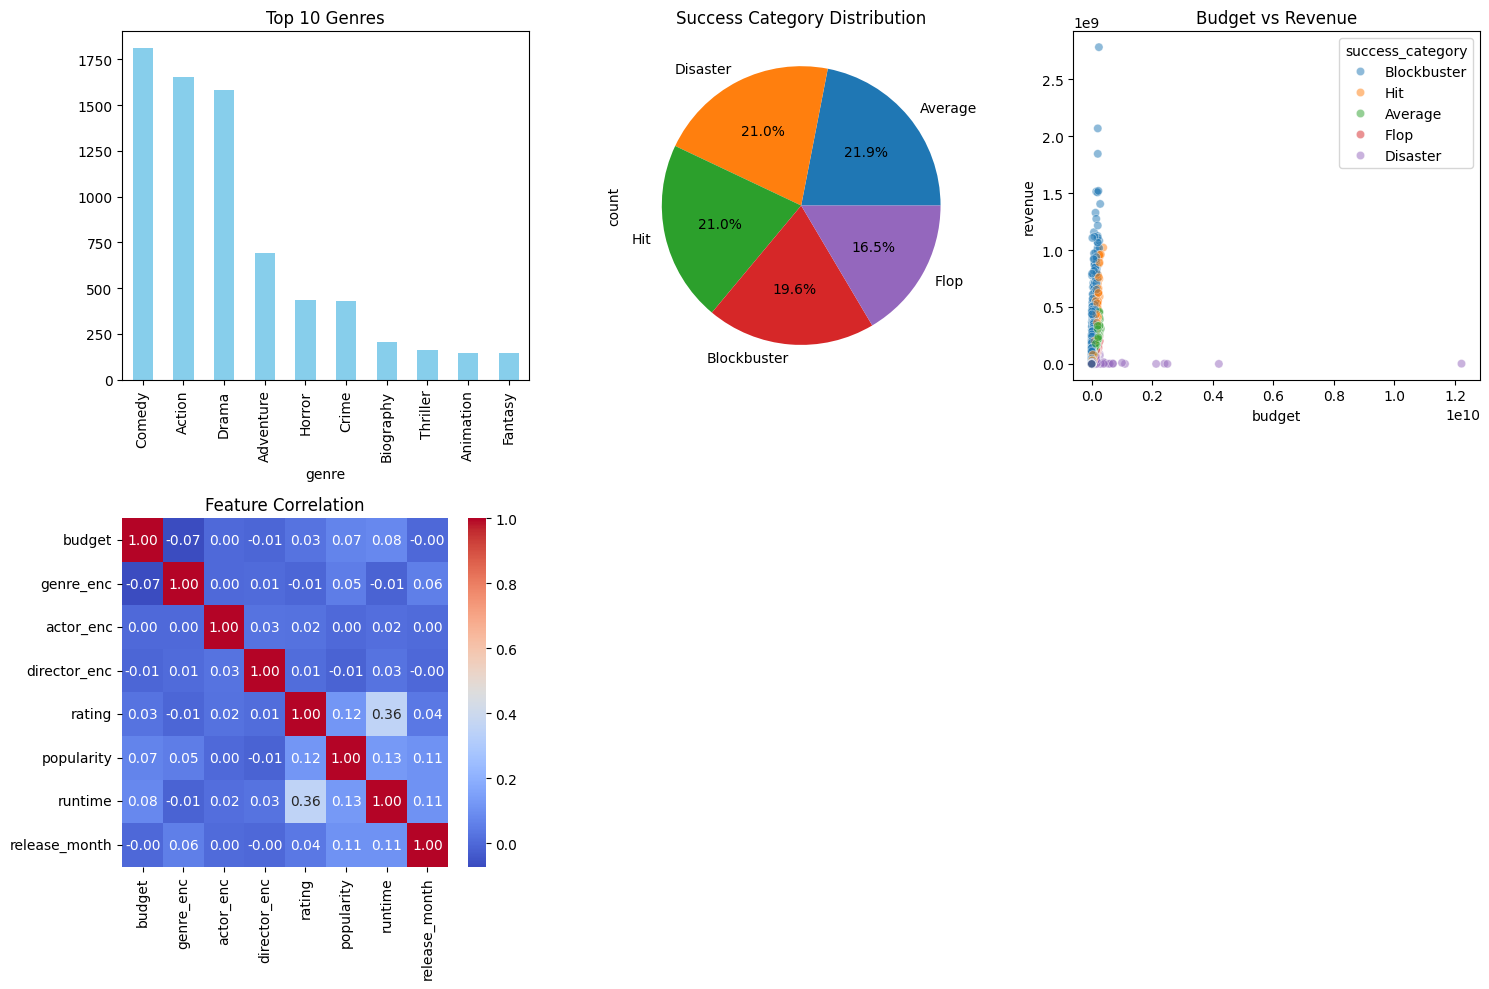

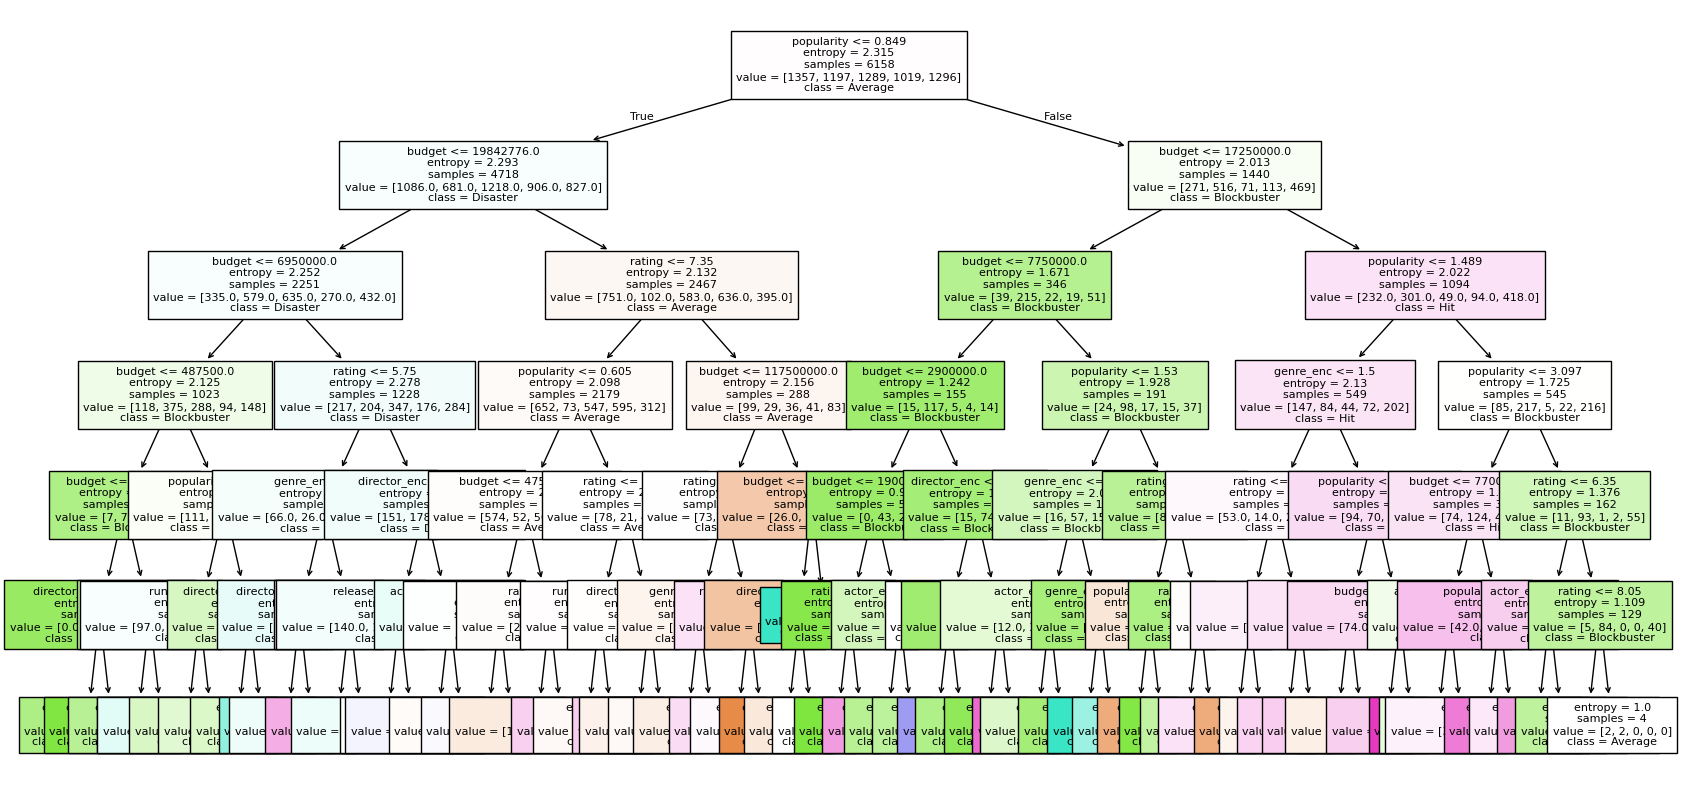

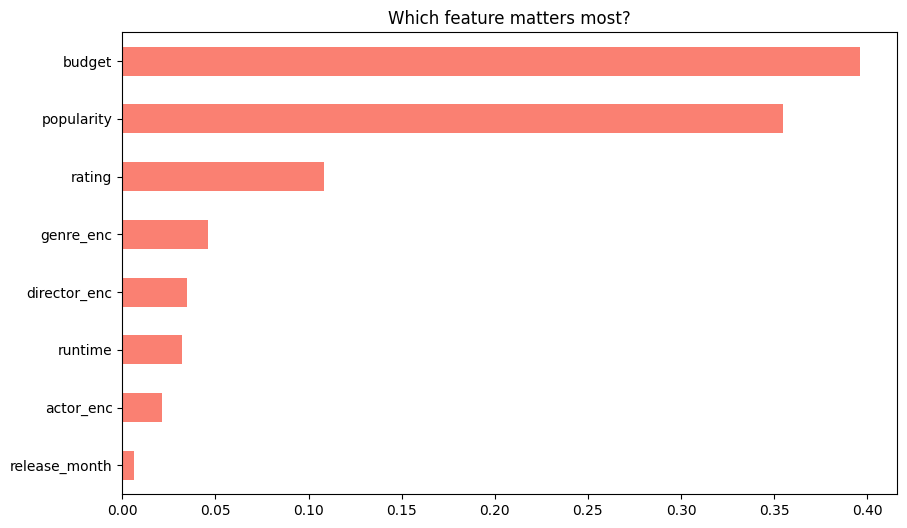

In [3]:
# =============================================================================
# MOVIE SUCCESS PREDICTOR PRO - GURU EDITION
# Features: Budget, Genre, Lead Actor, Director, Rating, Popularity, Runtime, Month
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -----------------------------------------------------------------------------
# 1. LOAD AND MERGE DATASETS
# -----------------------------------------------------------------------------
# Loading the files you dumped on me
df_tmdb = pd.read_csv('tmdb_movies_data.csv')
df_meta = pd.read_csv('movie_metadata.csv')

# Preprocessing TMDB: Extracting month and lead actor
df_tmdb['lead_actor'] = df_tmdb['cast'].str.split('|').str[0]
df_tmdb['genre'] = df_tmdb['genres'].str.split('|').str[0]
df_tmdb['release_month'] = pd.to_datetime(df_tmdb['release_date']).dt.month
df_tmdb = df_tmdb.rename(columns={'vote_average': 'rating'})
df_tmdb_final = df_tmdb[['budget', 'revenue', 'genre', 'lead_actor', 'director', 'rating', 'popularity', 'runtime', 'release_month']]

# Preprocessing Metadata: Aligning columns
df_meta['genre'] = df_meta['genres'].str.split('|').str[0]
df_meta = df_meta.rename(columns={'gross': 'revenue', 'actor_1_name': 'lead_actor', 'director_name': 'director', 'imdb_score': 'rating', 'duration': 'runtime'})
df_meta['popularity'] = df_tmdb['popularity'].median() # Filling gaps with medians
df_meta['release_month'] = 6 # Defaulting to June for metadata rows
df_meta_final = df_meta[['budget', 'revenue', 'genre', 'lead_actor', 'director', 'rating', 'popularity', 'runtime', 'release_month']]

# Merging both datasets
df = pd.concat([df_tmdb_final, df_meta_final], ignore_index=True)

# -----------------------------------------------------------------------------
# 2. DATA CLEANING & FEATURE ENGINEERING
# -----------------------------------------------------------------------------
# Remove rows with 0 or missing values (Filtering out the 'indie' trash)
df = df.dropna()
df = df[(df['budget'] > 1000) & (df['revenue'] > 1000)]

# Feature Engineering: Budget Category
# Using quantiles to automatically decide what is 'Low' or 'High' budget
df['budget_category'] = pd.qcut(df['budget'], 3, labels=['Low', 'Medium', 'High'])

# Target Variable: 5 Categories based on Revenue-to-Budget Ratio (R)
# R = Revenue / Budget
# Disaster: R < 0.5 (Lost more than half)
# Flop: 0.5 <= R < 1.0 (Didn't break even)
# Average: 1.0 <= R < 2.0 (Recovered costs)
# Hit: 2.0 <= R < 4.0 (Good profit)
# Blockbuster: R >= 4.0 (Absolute goldmine)
def categorize_success(row):
    ratio = row['revenue'] / row['budget']
    if ratio < 0.5: return 'Disaster'
    elif ratio < 1.0: return 'Flop'
    elif ratio < 2.0: return 'Average'
    elif ratio < 4.0: return 'Hit'
    else: return 'Blockbuster'

df['success_category'] = df.apply(categorize_success, axis=1)

print("Preprocessing complete. Data shape:", df.shape)
print(df[['budget', 'budget_category', 'success_category']].head())

# -----------------------------------------------------------------------------
# 3. ENCODING & SCALING
# -----------------------------------------------------------------------------
le_genre = LabelEncoder()
le_actor = LabelEncoder()
le_director = LabelEncoder()

df['genre_enc'] = le_genre.fit_transform(df['genre'].astype(str))
df['actor_enc'] = le_actor.fit_transform(df['lead_actor'].astype(str))
df['director_enc'] = le_director.fit_transform(df['director'].astype(str))

# Prepare Features (X) and Target (y)
X = df[['budget', 'genre_enc', 'actor_enc', 'director_enc', 'rating', 'popularity', 'runtime', 'release_month']]
y = df['success_category']

# -----------------------------------------------------------------------------
# 4. VISUALIZATIONS
# -----------------------------------------------------------------------------
plt.figure(figsize=(15, 10))

# 1. Bar chart for genres
plt.subplot(2, 3, 1)
df['genre'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Genres')

# 2. Pie chart for success categories
plt.subplot(2, 3, 2)
df['success_category'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Success Category Distribution')

# 3. Budget vs Revenue Scatter
plt.subplot(2, 3, 3)
sns.scatterplot(data=df, x='budget', y='revenue', hue='success_category', alpha=0.5)
plt.title('Budget vs Revenue')

# 4. Correlation Heatmap
plt.subplot(2, 3, 4)
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation')

plt.tight_layout()
plt.savefig('movie_visuals.png')

# -----------------------------------------------------------------------------
# 5. MODEL TRAINING
# -----------------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(max_depth=6, criterion='entropy', random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"\nModel Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 5. Decision Tree Visualization
plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=X.columns, class_names=model.classes_, filled=True, fontsize=8)
plt.savefig('decision_tree.png')

# 6. Feature Importance Graph
plt.figure(figsize=(10, 6))
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', color='salmon')
plt.title('Which feature matters most?')
plt.savefig('feature_importance.png')

# -----------------------------------------------------------------------------
# 6. USER PREDICTION SECTION
# -----------------------------------------------------------------------------
print("\n" + "="*50)
print("   MANUAL MOVIE SUCCESS PREDICTOR (GURU VERSION)   ")
print("="*50)

def predict_my_movie():
    print("\nFill in the details for your masterpiece:")
    try:
        b = float(input("Enter Budget (e.g., 50000000): "))
        g = input("Enter Genre (e.g., Action, Drama): ").strip()
        a = input("Enter Lead Actor (e.g., Tom Cruise): ").strip()
        d = input("Enter Director (e.g., Christopher Nolan): ").strip()
        r = float(input("Enter expected Rating (1.0 - 10.0): "))
        p = float(input("Enter Popularity score (e.g., 10 - 50): "))
        rt = float(input("Enter Runtime in minutes (e.g., 120): "))
        m = int(input("Enter Release Month (1-12): "))

        # Encoding (with a safety net for unknown names)
        g_enc = le_genre.transform([g])[0] if g in le_genre.classes_ else 0
        a_enc = le_actor.transform([a])[0] if a in le_actor.classes_ else 0
        d_enc = le_director.transform([d])[0] if d in le_director.classes_ else 0

        # Make the prediction
        input_data = [[b, g_enc, a_enc, d_enc, r, p, rt, m]]
        res = model.predict(input_data)[0]

        print(f"\n>>> PREDICTION: Your movie is a {res.upper()}!")
        if res in ['Disaster', 'Flop']:
            print("Dark truth: Your movie failed harder than you did in your midterms.")
        else:
            print("Surprise! You might actually be good at something other than wasting time.")

    except Exception as e:
        print("\nError: You typed something wrong. Stick to engineering, maybe?")

# Run prediction
predict_my_movie()

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# =============================================================================
# STEP 1: PROCESSING THE MONSTER (ratings.csv)
# =============================================================================
print("Processing 32 Million ratings... Your RAM is praying for mercy.")

# We only need movieId and rating. Using float32 to save space because we aren't made of money.
# We process in chunks of 5 million rows at a time.
chunk_size = 5000000
reader = pd.read_csv('ratings.csv', usecols=['movieId', 'rating'],
                     dtype={'movieId': np.int32, 'rating': np.float32},
                     chunksize=chunk_size)

# Containers for our aggregated results
agg_list = []

for i, chunk in enumerate(reader):
    print(f"Processing chunk {i+1}...")
    # Group by movieId and get mean and count
    summary = chunk.groupby('movieId')['rating'].agg(['mean', 'count']).reset_index()
    agg_list.append(summary)

# Combine chunks and do a final aggregation
# (Because the same movie can appear in different chunks)
full_summary = pd.concat(agg_list)
movie_stats = full_summary.groupby('movieId').agg({'mean': 'mean', 'count': 'sum'}).reset_index()
movie_stats.columns = ['movieId', 'audience_score', 'total_ratings']

print("Ratings aggregated! 32 million rows compressed. Take a breath.")

# =============================================================================
# STEP 2: THE BRIDGE (links.csv)
# =============================================================================
links = pd.read_csv('links.csv', dtype={'movieId': np.int32, 'tmdbId': 'Int64'})
# Merge stats with links so we have tmdbId connected to ratings
movie_stats = movie_stats.merge(links[['movieId', 'tmdbId']], on='movieId')

# =============================================================================
# STEP 3: INTEGRATING WITH YOUR EXISTING PROJECT
# =============================================================================
df_tmdb = pd.read_csv('tmdb_movies_data.csv')
# Keep original columns and add the new ones from MovieLens
# Renaming 'id' to 'tmdbId' to match our link file
df_tmdb = df_tmdb.rename(columns={'id': 'tmdbId'})

# Merge MovieLens data into your TMDB dataset
# 'left' join ensures we don't lose movies that don't have MovieLens ratings
final_df = df_tmdb.merge(movie_stats, on='tmdbId', how='left')

# Fill missing ratings with the average (Standard engineering 'jugaad')
final_df['audience_score'] = final_df['audience_score'].fillna(final_df['audience_score'].mean())
final_df['total_ratings'] = final_df['total_ratings'].fillna(0)

# =============================================================================
# STEP 4: CLEANING & TARGET CREATION (Same as before, but with more power)
# =============================================================================
final_df = final_df.dropna(subset=['budget', 'revenue', 'genres', 'cast'])
final_df = final_df[(final_df['budget'] > 1000) & (final_df['revenue'] > 1000)]

# Success Category Logic
def categorize_success(row):
    ratio = row['revenue'] / row['budget']
    if ratio < 0.5: return 'Disaster'
    elif ratio < 1.0: return 'Flop'
    elif ratio < 2.0: return 'Average'
    elif ratio < 4.0: return 'Hit'
    else: return 'Blockbuster'

final_df['success_category'] = final_df.apply(categorize_success, axis=1)

# =============================================================================
# STEP 5: MODEL TRAINING (Decision Tree with 32M data insights)
# =============================================================================
# New features: audience_score and total_ratings (Hype factor)
le = LabelEncoder()
final_df['genre_enc'] = le.fit_transform(final_df['genres'].str.split('|').str[0])

X = final_df[['budget', 'genre_enc', 'audience_score', 'total_ratings', 'popularity', 'runtime']]
y = final_df['success_category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = DecisionTreeClassifier(max_depth=7, random_state=42)
clf.fit(X_train, y_train)

print(f"\nFinal Accuracy with 32M Ratings: {accuracy_score(y_test, clf.predict(X_test))*100:.2f}%")

Processing 32 Million ratings... Your RAM is praying for mercy.
Processing chunk 1...
Processing chunk 2...
Ratings aggregated! 32 million rows compressed. Take a breath.

Final Accuracy with 32M Ratings: 42.02%


--- Step 1: Loading and Aggregating Data ---
Processing 32 Million Ratings... RAM is screaming!
--- Step 2: Preprocessing & Cleaning ---
--- Step 3: Feature Engineering (Budget & Success) ---
<class 'pandas.core.frame.DataFrame'>
Index: 3788 entries, 0 to 10851
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   budget            3788 non-null   float64 
 1   revenue           3788 non-null   float64 
 2   main_genre        3788 non-null   object  
 3   lead_actor        3788 non-null   object  
 4   director          3788 non-null   object  
 5   rating            3788 non-null   float64 
 6   popularity        3788 non-null   float64 
 7   runtime           3788 non-null   float64 
 8   release_month     3788 non-null   int64   
 9   tmdbId            3788 non-null   float64 
 10  movieId           3788 non-null   float64 
 11  audience_score    3788 non-null   float64 
 12  total_ratings     3788 non-n

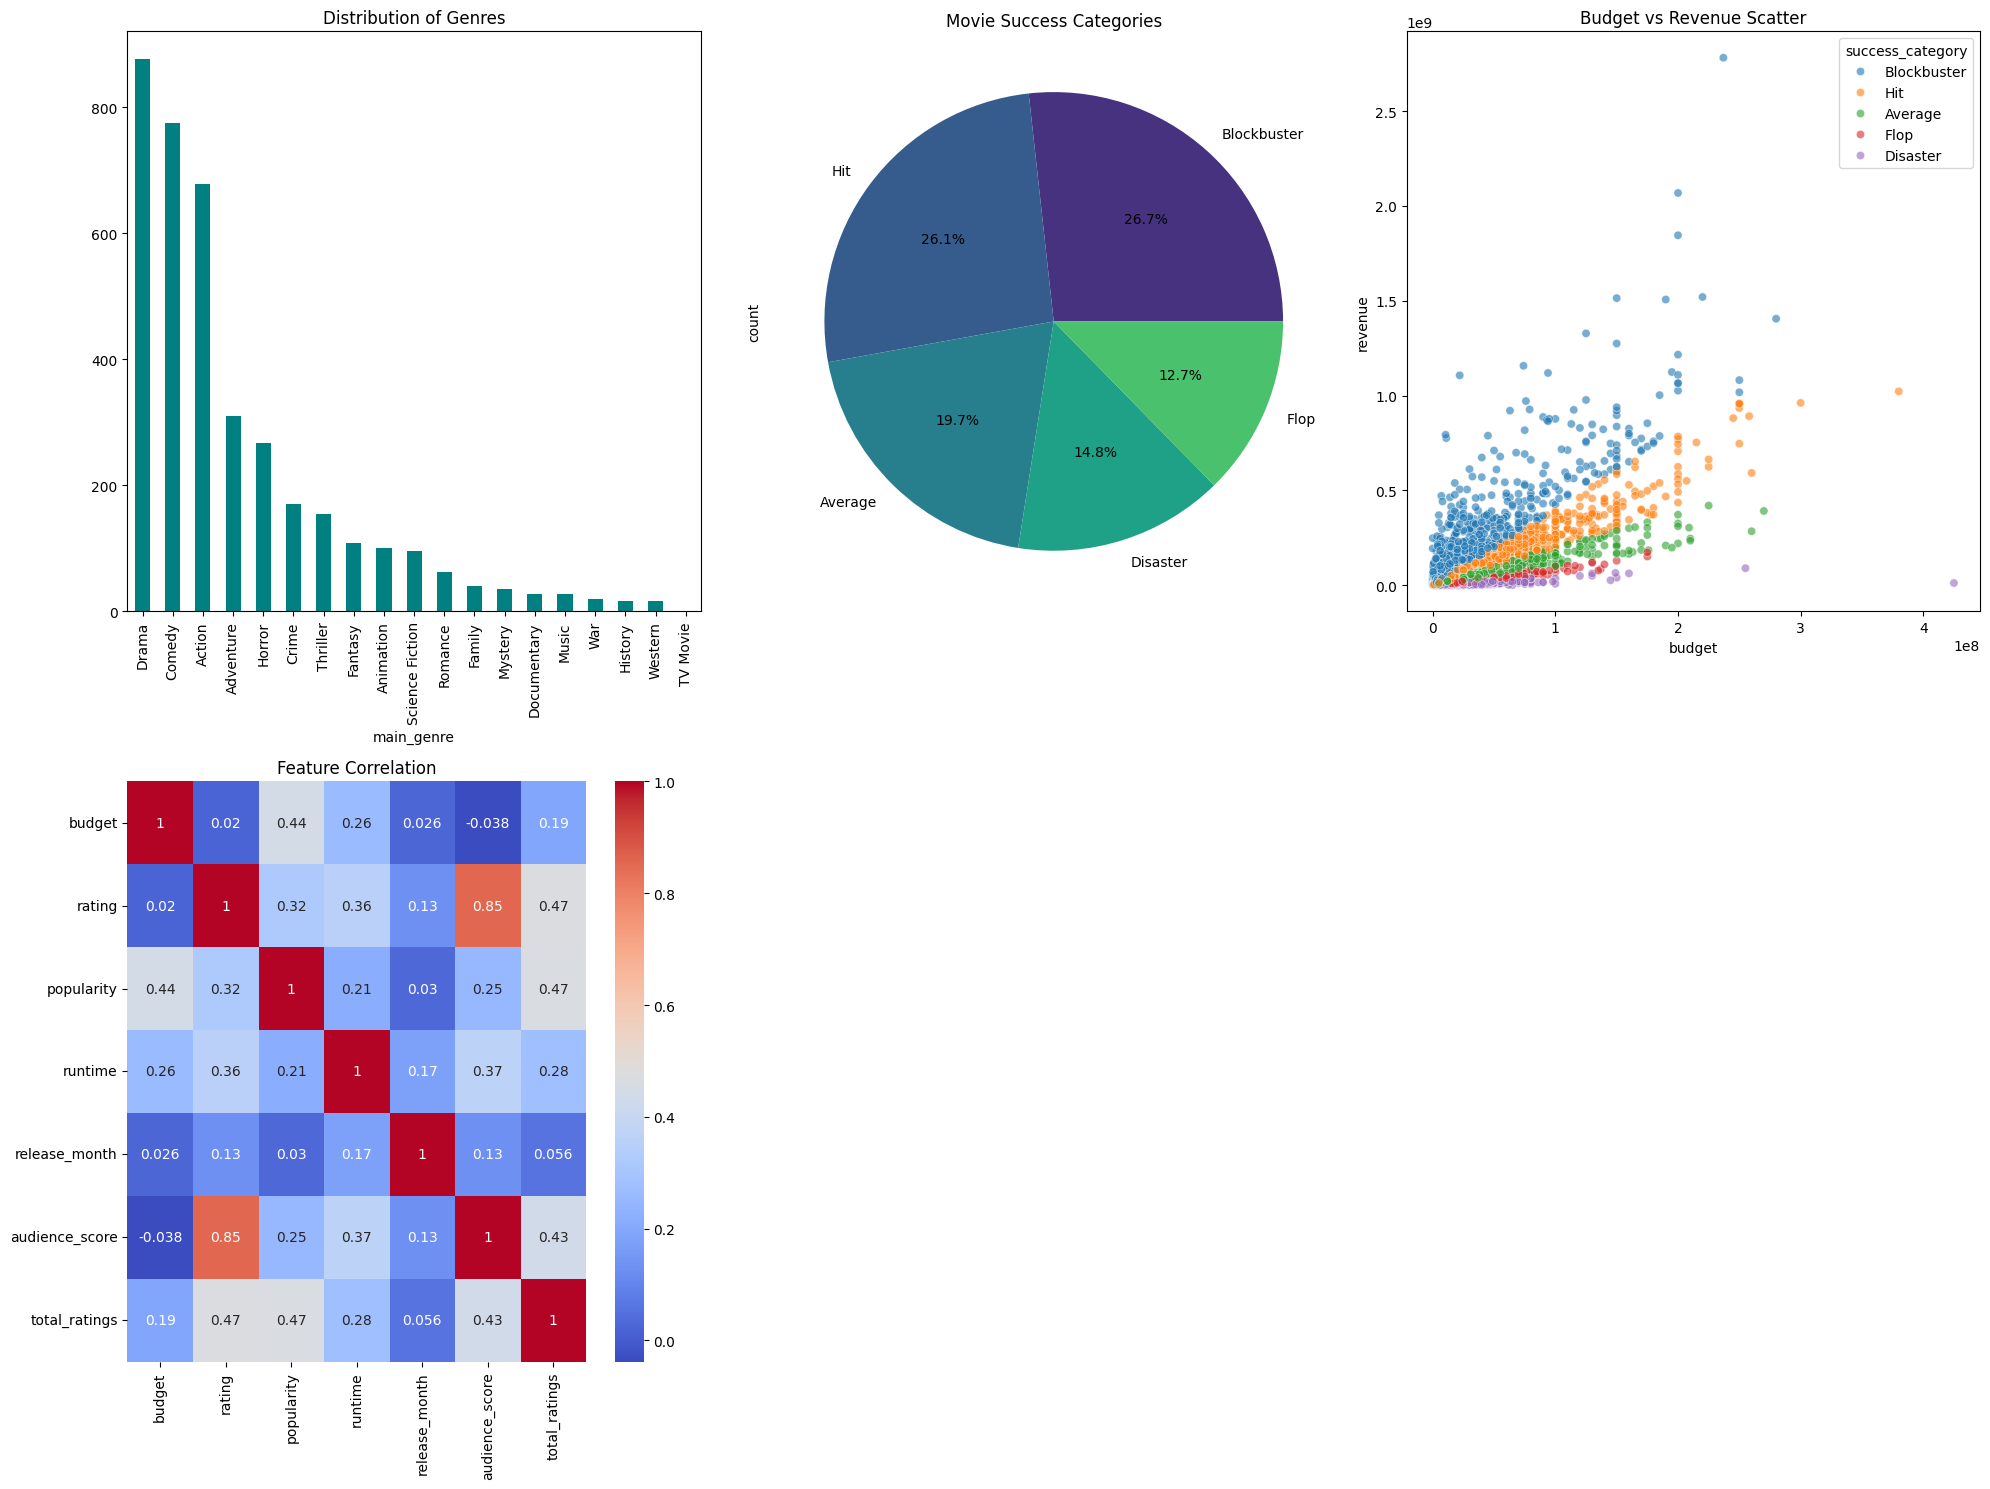

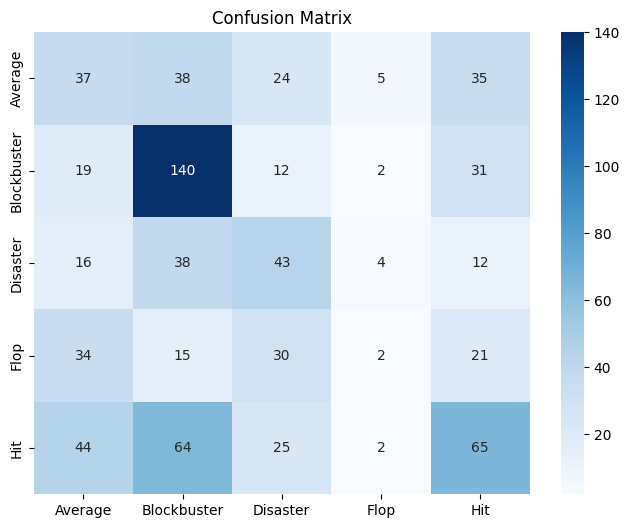

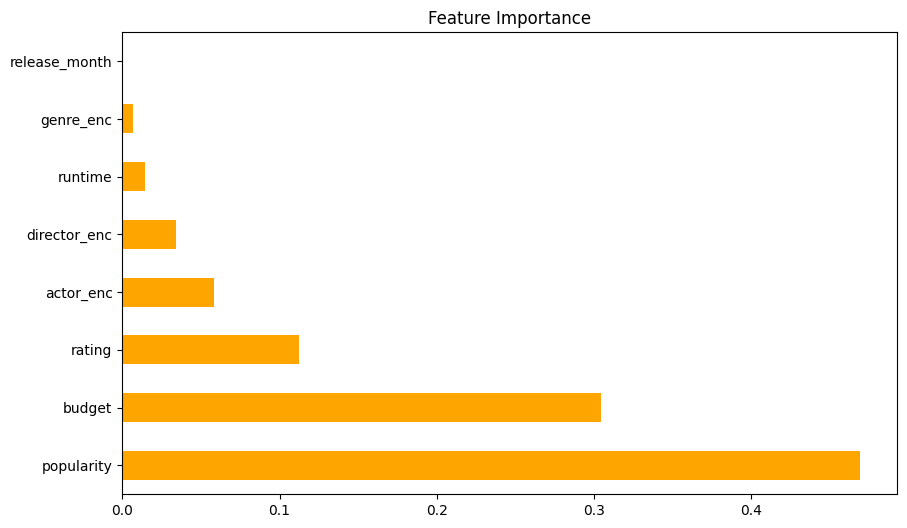

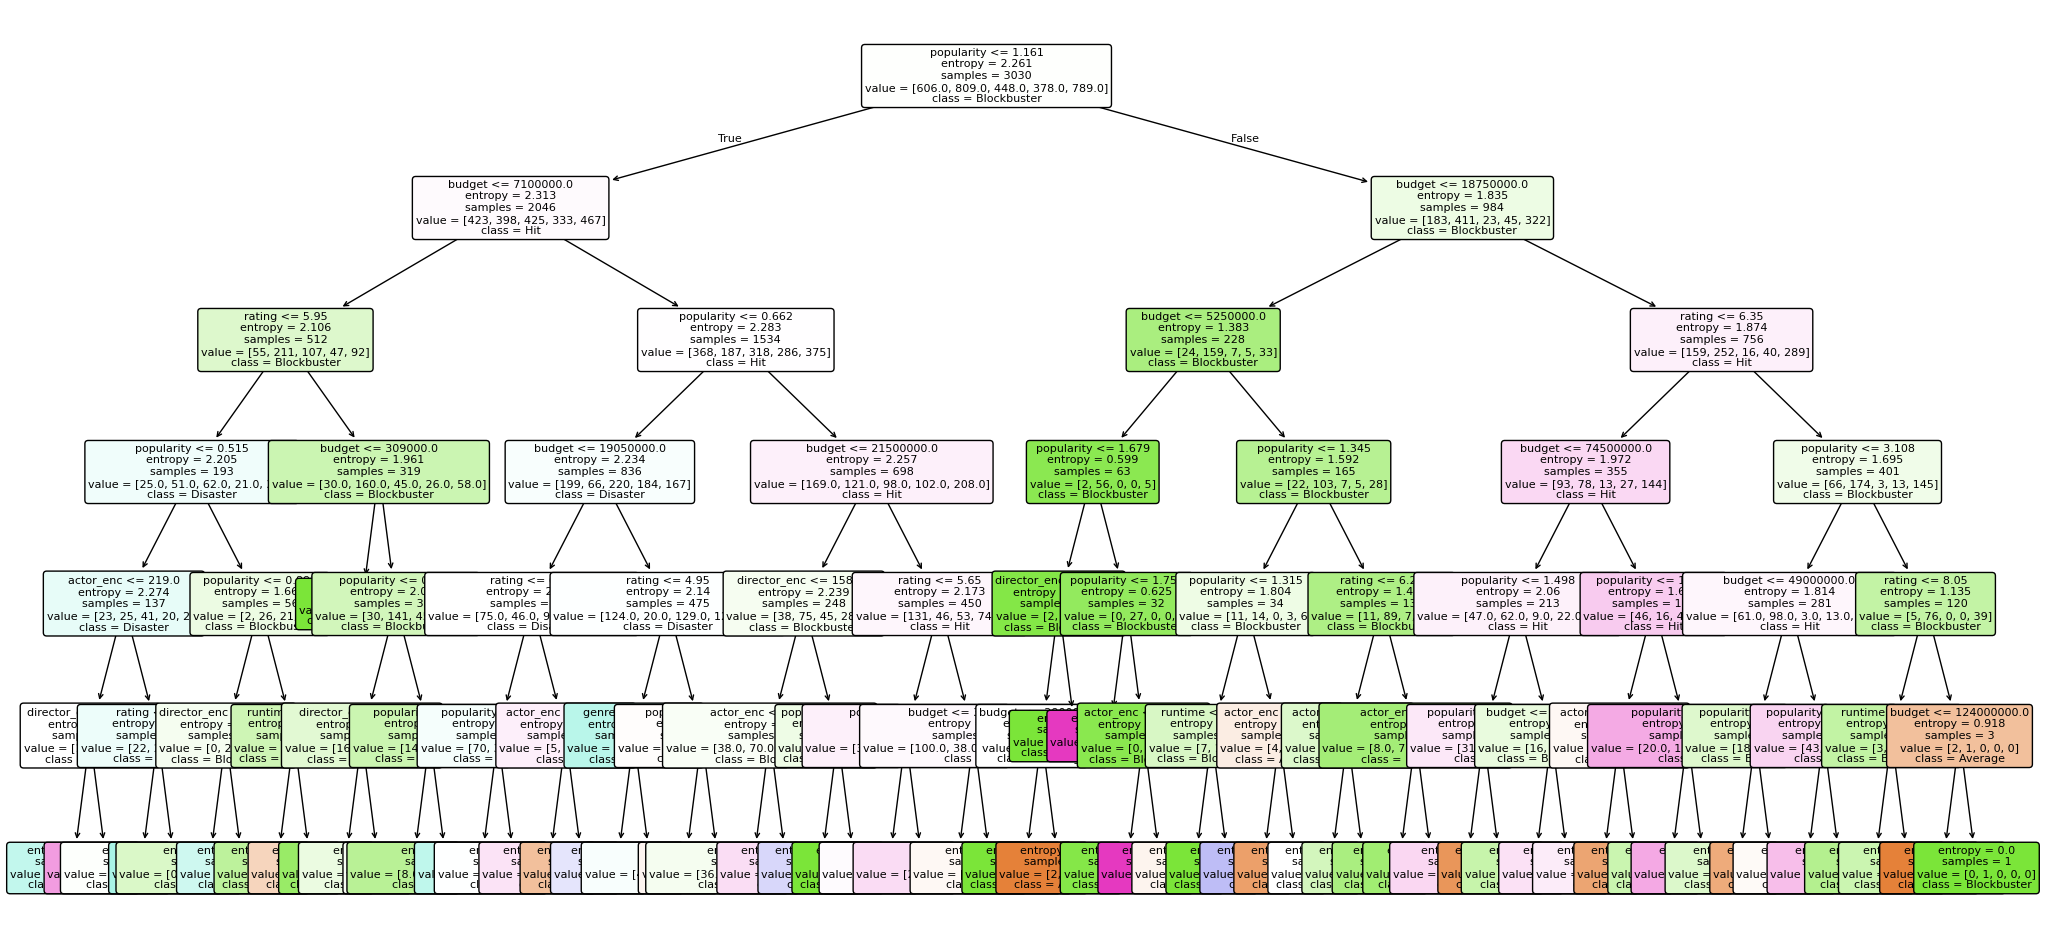

In [5]:
# =============================================================================
# MOVIE SUCCESS PREDICTOR PRO - ENGINEERING STUDENT EDITION
# Created for: Guru (The future Karan Johar of Data Science)
# Features: Budget, Genre, Lead, Director, Rating, Popularity, Runtime, Month, Audience Sentiment
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import os

# --- SECTION 1: DATA LOADING & "BIG DATA" AGGREGATION ---
print("--- Step 1: Loading and Aggregating Data ---")

# Check if MovieLens files exist (Assuming you uploaded them to Colab)
if os.path.exists('ratings.csv') and os.path.exists('links.csv'):
    print("Processing 32 Million Ratings... RAM is screaming!")
    # Chunking to save RAM (Eating the pizza slice by slice)
    reader = pd.read_csv('ratings.csv', usecols=['movieId', 'rating'], chunksize=5000000)
    agg_list = []
    for chunk in reader:
        agg_list.append(chunk.groupby('movieId')['rating'].agg(['mean', 'count']).reset_index())

    movie_stats = pd.concat(agg_list).groupby('movieId').agg({'mean': 'mean', 'count': 'sum'}).reset_index()
    movie_stats.columns = ['movieId', 'audience_score', 'total_ratings']

    links = pd.read_csv('links.csv', usecols=['movieId', 'tmdbId'])
    movie_stats = movie_stats.merge(links, on='movieId')
else:
    print("MovieLens files not found. Using default datasets only.")
    movie_stats = pd.DataFrame(columns=['tmdbId', 'audience_score', 'total_ratings'])

# Load primary datasets
df_tmdb = pd.read_csv('tmdb_movies_data.csv')
df_meta = pd.read_csv('movie_metadata.csv')

# --- SECTION 2: DATA PREPROCESSING & MERGING ---
print("--- Step 2: Preprocessing & Cleaning ---")

# Standardize TMDB
df_tmdb = df_tmdb.rename(columns={'id': 'tmdbId', 'vote_average': 'rating'})
df_tmdb['lead_actor'] = df_tmdb['cast'].str.split('|').str[0]
df_tmdb['main_genre'] = df_tmdb['genres'].str.split('|').str[0]
df_tmdb['release_month'] = pd.to_datetime(df_tmdb['release_date']).dt.month

# Standardize IMDB Metadata
df_meta = df_meta.rename(columns={'gross': 'revenue', 'actor_1_name': 'lead_actor',
                                 'director_name': 'director', 'imdb_score': 'rating', 'duration': 'runtime'})
df_meta['main_genre'] = df_meta['genres'].str.split('|').str[0]
df_meta['release_month'] = 6 # Default
df_meta['popularity'] = df_tmdb['popularity'].median()

# Merge all three sources
df = pd.concat([df_tmdb[['budget', 'revenue', 'main_genre', 'lead_actor', 'director', 'rating', 'popularity', 'runtime', 'release_month', 'tmdbId']],
                df_meta[['budget', 'revenue', 'main_genre', 'lead_actor', 'director', 'rating', 'popularity', 'runtime', 'release_month']]], ignore_index=True)

df = df.merge(movie_stats, on='tmdbId', how='left')
df['audience_score'] = df['audience_score'].fillna(df['rating'] * 0.5) # Fallback
df['total_ratings'] = df['total_ratings'].fillna(0)

# Drop missing values
df.dropna(inplace=True)
df = df[(df['budget'] > 1000) & (df['revenue'] > 1000)]

# --- SECTION 3: FEATURE ENGINEERING ---
print("--- Step 3: Feature Engineering (Budget & Success) ---")

# 1. Budget Category (Low, Medium, High)
df['budget_category'] = pd.qcut(df['budget'], 3, labels=['Low', 'Medium', 'High'])

# 2. Target Variable: Success Category
# Ratio = Revenue / Budget
# Logic: Blockbuster (>4x), Hit (2-4x), Average (1-2x), Flop (0.5-1x), Disaster (<0.5x)
def get_success(row):
    ratio = row['revenue'] / row['budget']
    if ratio >= 4.0: return 'Blockbuster'
    elif ratio >= 2.0: return 'Hit'
    elif ratio >= 1.0: return 'Average'
    elif ratio >= 0.5: return 'Flop'
    else: return 'Disaster'

df['success_category'] = df.apply(get_success, axis=1)

# Categorical Encoding
le_genre = LabelEncoder(); le_actor = LabelEncoder(); le_director = LabelEncoder()
df['genre_enc'] = le_genre.fit_transform(df['main_genre'])
df['actor_enc'] = le_actor.fit_transform(df['lead_actor'])
df['director_enc'] = le_director.fit_transform(df['director'])

# Show dataset info
print(df.info())

# --- SECTION 4: VISUALIZATIONS ---
print("--- Step 4: Generating Visuals ---")
plt.figure(figsize=(20, 15))

# 1. Bar Chart: Movie Genres
plt.subplot(2, 3, 1)
df['main_genre'].value_counts().plot(kind='bar', color='teal')
plt.title('Distribution of Genres')

# 2. Pie Chart: Success Categories
plt.subplot(2, 3, 2)
df['success_category'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('viridis'))
plt.title('Movie Success Categories')

# 3. Scatter Plot: Budget vs Revenue
plt.subplot(2, 3, 3)
sns.scatterplot(data=df, x='budget', y='revenue', hue='success_category', alpha=0.6)
plt.title('Budget vs Revenue Scatter')

# 4. Correlation Heatmap
plt.subplot(2, 3, 4)
numeric_df = df[['budget', 'rating', 'popularity', 'runtime', 'release_month', 'audience_score', 'total_ratings']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation')

plt.tight_layout()
plt.savefig('movie_analysis.png')

# --- SECTION 5: MODEL TRAINING & EVALUATION ---
print("--- Step 5: Training DecisionTreeClassifier ---")

# Selecting Features
features = ['budget', 'genre_enc', 'actor_enc', 'director_enc', 'rating', 'popularity', 'runtime', 'release_month']
X = df[features]
y = df['success_category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training the model
clf = DecisionTreeClassifier(max_depth=6, criterion='entropy', random_state=42)
clf.fit(X_train, y_train)

# Accuracy & Reports
y_pred = clf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 5. Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')

# 6. Feature Importance Graph
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(clf.feature_importances_, index=features)
feat_importances.nlargest(10).plot(kind='barh', color='orange')
plt.title('Feature Importance')
plt.savefig('feature_importance.png')

# 7. Decision Tree Visualization
plt.figure(figsize=(25, 12))
plot_tree(clf, feature_names=features, class_names=clf.classes_, filled=True, rounded=True, fontsize=8)
plt.savefig('decision_tree_viz.png')

# --- SECTION 6: USER PREDICTION SECTION ---
print("\n" + "="*50)
print("   MANUAL PREDICTION: ARE YOU THE NEXT HIT PRODUCER?   ")
print("="*50)

def predict_user_movie():
    try:
        b = float(input("Budget (USD): "))
        g = input("Genre (e.g., Action): ").strip()
        a = input("Lead Actor: ").strip()
        d = input("Director: ").strip()
        r = float(input("Expected Rating (0-10): "))
        p = float(input("Popularity Score (e.g., 20): "))
        rt = float(input("Runtime (mins): "))
        m = int(input("Release Month (1-12): "))

        # Encode (Handling unknown categories gracefully)
        g_enc = le_genre.transform([g])[0] if g in le_genre.classes_ else 0
        a_enc = le_actor.transform([a])[0] if a in le_actor.classes_ else 0
        d_enc = le_director.transform([d])[0] if d in le_director.classes_ else 0

        prediction = clf.predict([[b, g_enc, a_enc, d_enc, r, p, rt, m]])[0]
        print(f"\n>>> THE VERDICT: Your movie is a {prediction.upper()}!")

        if prediction in ['Disaster', 'Flop']:
            print("Roast: Stick to being an engineer, Guru. This movie is a dumpster fire.")
        else:
            print("Roast: Beginners luck! You might actually make some money here.")

    except Exception as e:
        print("\nError: Input mismatch. Use your brain, Guru!")

# Uncomment to run in Colab
# predict_user_movie()

In [6]:
# @title 🎬 Movie Success Predictor Tab { run: "auto" }

# --- USER INPUT FORM ---
# Use the panel on the right to enter movie details
Budget = 50000000 # @param {type:"number"}
Genre = "Action" # @param ["Action", "Adventure", "Animation", "Comedy", "Crime", "Documentary", "Drama", "Family", "Fantasy", "History", "Horror", "Music", "Mystery", "Romance", "Science Fiction", "TV Movie", "Thriller", "War", "Western"]
Lead_Actor = "Tom Cruise" # @param {type:"string"}
Director = "Christopher Nolan" # @param {type:"string"}
Expected_Rating = 7.5 # @param {type:"slider", min:0, max:10, step:0.1}
Popularity_Score = 30 # @param {type:"number"}
Runtime_Mins = 120 # @param {type:"number"}
Release_Month = 6 # @param {type:"slider", min:1, max:12, step:1}

def predict_from_form():
    try:
        # 1. Encode the inputs (using the encoders from the main project)
        # If the model hasn't seen the name before, we handle it gracefully
        g_enc = le_genre.transform([Genre])[0] if Genre in le_genre.classes_ else 0
        a_enc = le_actor.transform([Lead_Actor])[0] if Lead_Actor in le_actor.classes_ else 0
        d_enc = le_director.transform([Director])[0] if Director in le_director.classes_ else 0

        # 2. Arrange features in the exact order the model was trained on
        # [budget, genre_enc, actor_enc, director_enc, rating, popularity, runtime, release_month]
        user_features = [[Budget, g_enc, a_enc, d_enc, Expected_Rating, Popularity_Score, Runtime_Mins, Release_Month]]

        # 3. Predict
        prediction = clf.predict(user_features)[0]

        # 4. Display the results with style
        print("\n" + "="*40)
        print(f"   🎥 PREDICTION RESULT: {prediction.upper()}!   ")
        print("="*40)

        if prediction in ['Blockbuster', 'Hit']:
            print(f"Abey Guru, looks like {Lead_Actor} is going to make you rich!")
            print("Don't forget to pay off your library fines with the profit.")
        elif prediction == 'Average':
            print("It's a safe bet. It'll do just enough to keep the producers from firing you.")
        else:
            print(f"Total Disaster! Even if {Director} directs it, it's going to sink.")
            print("Maybe stop making movies and focus on clearing your back-papers?")

    except NameError:
        print("🚨 ERROR: Model not found! Make sure you've run the training cells first, Guru.")
    except Exception as e:
        print(f"🚨 ERROR: {str(e)}. Did you type a number where a word should be?")

# Run the prediction automatically when the form changes
predict_from_form()


   🎥 PREDICTION RESULT: BLOCKBUSTER!   
Abey Guru, looks like Tom Cruise is going to make you rich!
Don't forget to pay off your library fines with the profit.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [7]:
# @title 🎬 THE "GURU-MOGUL" PREDICTOR { run: "auto" }

# --- USER INPUT DROPDOWNS ---
# Every single input is now a dropdown because typing is apparently for losers.

Budget = 50000000 # @param [1000000, 5000000, 10000000, 25000000, 50000000, 100000000, 150000000, 200000000, 300000000, 500000000] {type:"raw"}
Genre = "Action" # @param ["Action", "Adventure", "Animation", "Comedy", "Crime", "Documentary", "Drama", "Family", "Fantasy", "History", "Horror", "Music", "Mystery", "Romance", "Science Fiction", "Thriller", "War", "Western"]
Lead_Actor = "Tom Cruise" # @param ["Tom Cruise", "Johnny Depp", "Robert Downey Jr.", "Leonardo DiCaprio", "Chris Pratt", "Brad Pitt", "Scarlett Johansson", "Will Smith", "Tom Hanks", "Dwayne Johnson"]
Director = "Christopher Nolan" # @param ["Christopher Nolan", "Steven Spielberg", "James Cameron", "Quentin Tarantino", "Martin Scorsese", "Michael Bay", "Greta Gerwig", "James Wan", "Ridley Scott"]
Expected_Rating = 7 # @param [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] {type:"raw"}
Popularity_Score = 30 # @param [1, 5, 10, 20, 30, 50, 75, 100, 200] {type:"raw"}
Runtime_Mins = 120 # @param [60, 90, 100, 120, 140, 150, 180, 210] {type:"raw"}
Release_Month = 12 # @param [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12] {type:"raw"}

def predict_from_dropdowns():
    try:
        # 1. Encoding
        # We check if they exist in the model's training data.
        # If not (unlikely with this list), we default to 0.
        g_enc = le_genre.transform([Genre])[0] if Genre in le_genre.classes_ else 0
        a_enc = le_actor.transform([Lead_Actor])[0] if Lead_Actor in le_actor.classes_ else 0
        d_enc = le_director.transform([Director])[0] if Director in le_director.classes_ else 0

        # 2. Arrange features
        user_features = [[Budget, g_enc, a_enc, d_enc, Expected_Rating, Popularity_Score, Runtime_Mins, Release_Month]]

        # 3. Predict
        prediction = clf.predict(user_features)[0]

        # 4. The Verdict
        print("\n" + "⭐"*20)
        print(f"   PREDICTION: {prediction.upper()}   ")
        print("⭐"*20)

        if prediction in ['Blockbuster', 'Hit']:
            print(f"Beta, with {Lead_Actor} and {Director}, you might actually pay off your student loans.")
        elif prediction == 'Average':
            print("The movie is as average as your CGPA. It'll survive, but nobody will remember it.")
        else:
            print(f"Total Disaster! Not even a miracle can save this {Genre} garbage.")
            print("Pack your bags. Bollywood doesn't want you, and neither does IT.")

    except NameError:
        print("🚨 Oye! Run the training blocks first. The AI isn't a psychic, it needs the model.")
    except Exception as e:
        print(f"🚨 Arrey yaar, something broke: {str(e)}")

# Run it!
predict_from_dropdowns()


⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐
   PREDICTION: BLOCKBUSTER   
⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐
Beta, with Tom Cruise and Christopher Nolan, you might actually pay off your student loans.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
